# Ghanaian Food Nutrition & Health Analyzer
### Using NumPy + Pandas + Seaborn + Matplotlip



## Introduction

In Ghana, we consume a wide variety of foods daily, but most people do not track the nutritional composition of what they eat.

This project uses **NumPy** and **Pandas** to analyze common Ghanaian foods based on their:
- Fat content
- Protein content
- Carbohydrate content

Using scientific calorie values, we compute total calories and classify foods into health categories.

I also applied normalization and visualization techniques to better understand patterns in the data.

**The goal is simple:**
>  Use data to make better food decisions.


## Dataset Creation

Each row represents a food item. Each column represents:
- **Fat (g)**
- **Protein (g)**
- **Carbohydrates (g)**

All values are estimated per 100g serving based on general nutritional references.

In [43]:
import numpy as np

foods = [
 [7.0, 4.0, 45.0],[2.0, 2.0, 40.0],[1.0, 2.0, 35.0],[6.0, 5.0, 50.0], [2.0, 3.0, 38.0],
 [11.0, 1.0, 31.0],[1.0, 9.0, 23.0],[10.0, 6.0, 48.0],[15.0, 26.0, 0.0],[12.0, 22.0, 0.0],
 [5.0, 3.0, 20.0],[3.0, 2.0, 30.0],[8.0, 3.0, 25.0],[20.0, 25.0, 10.0],[18.0, 20.0, 5.0],
 [4.0, 6.0, 35.0],[9.0, 8.0, 40.0],[13.0, 5.0, 42.0],[6.0, 4.0, 33.0],[14.0, 7.0, 28.0]
]

food_names = [
"Jollof Rice","Banku","Fufu","Waakye","Kenkey","Fried Plantain",
"Boiled Beans","Fried Rice","Grilled Chicken","Fried Fish",
"Yam","Cassava","Boiled Plantain","Groundnut Soup","Palm Nut Soup",
"Rice Balls","Beans Stew","Spaghetti Jollof","Hausa Koko","Meat Pie"
]

## Calories Calculation (Broadcasting)

We use standard scientific values:
- **Fat** = 9 kcal per gram
- **Protein** = 4 kcal per gram
- **Carbohydrates** = 4 kcal per gram

Using **NumPy broadcasting**, I multiplied all foods at once without loops.

This is efficient and scalable for large datasets.

In [44]:
calories_per_gram = np.array([9, 4, 4])

foods_np = np.array(foods)

calories = foods_np * calories_per_gram
total_calories = calories.sum(axis=1)


### Understanding the Data Structure and Calculations

Before moving forward, let's inspect the structure of our data and the results of our calculations.

Below, I will print:

- **Food Shape** to understand how the food dataset is arranged (rows and columns)
- **Rank (ndim)** to see the number of dimensions in the dataset
- **Data Type (dtype)** to identify the type of values stored in the array

I will also check the **calories per gram array** by printing:

- Its shape
- Its number of dimensions
- Its data type

Finally, I will display:

- **Calories per food** calculated using NumPy broadcasting
- **Total calories** computed by summing across nutrients for each food

This helps confirm that the data is structured correctly and that the calculations are working as expected.

In [45]:
print("Food Data Shape:", foods_np.shape)
print("Food Data Rank (Dimensions):", foods_np.ndim)
print("Food Data Type:", foods_np.dtype)

print("\nCalories Per Gram Shape:", calories_per_gram.shape)
print("Calories Per Gram Rank (Dimensions):", calories_per_gram.ndim)
print("Calories Per Gram Data Type:", calories_per_gram.dtype)

print("\nCalories Per Nutrient (After Broadcasting):")
print(calories)

print("\nTotal Calories Per Food:")
print(total_calories)

Food Data Shape: (20, 3)
Food Data Rank (Dimensions): 2
Food Data Type: float64

Calories Per Gram Shape: (3,)
Calories Per Gram Rank (Dimensions): 1
Calories Per Gram Data Type: int64

Calories Per Nutrient (After Broadcasting):
[[ 63.  16. 180.]
 [ 18.   8. 160.]
 [  9.   8. 140.]
 [ 54.  20. 200.]
 [ 18.  12. 152.]
 [ 99.   4. 124.]
 [  9.  36.  92.]
 [ 90.  24. 192.]
 [135. 104.   0.]
 [108.  88.   0.]
 [ 45.  12.  80.]
 [ 27.   8. 120.]
 [ 72.  12. 100.]
 [180. 100.  40.]
 [162.  80.  20.]
 [ 36.  24. 140.]
 [ 81.  32. 160.]
 [117.  20. 168.]
 [ 54.  16. 132.]
 [126.  28. 112.]]

Total Calories Per Food:
[259. 186. 157. 274. 182. 227. 137. 306. 239. 196. 137. 155. 184. 320.
 262. 200. 273. 305. 202. 266.]


## DataFrame Creation

In [46]:
import pandas as pd

df = pd.DataFrame(foods_np, columns=["Fat", "Protein", "Carbs"])
df["Food"] = food_names
df["Calories"] = total_calories

df

,Fat,Protein,Carbs,Food,Calories
0,7.0,4.0,45.0,Jollof Rice,259.0
1,2.0,2.0,40.0,Banku,186.0
2,1.0,2.0,35.0,Fufu,157.0
3,6.0,5.0,50.0,Waakye,274.0
4,2.0,3.0,38.0,Kenkey,182.0
5,11.0,1.0,31.0,Fried Plantain,227.0
6,1.0,9.0,23.0,Boiled Beans,137.0
7,10.0,6.0,48.0,Fried Rice,306.0
8,15.0,26.0,0.0,Grilled Chicken,239.0
9,12.0,22.0,0.0,Fried Fish,196.0



##  Health Classification

Foods are classified based on calorie ranges:
- **Healthy:** < 240 kcal
- **Moderate:** 240–300 kcal
- **High Calorie:** > 300 kcal

This helps us quickly identify foods that may contribute to excessive calorie intake.

In [47]:
health_labels = np.array(["High Calorie", "Moderate", "Healthy"])

df["Health"] = np.where(
    df["Calories"] > 300, health_labels[0],
    np.where(df["Calories"] > 240, health_labels[1], health_labels[2])
)
df[["Food", "Calories", "Health"]]

,Food,Calories,Health
0,Jollof Rice,259.0,Moderate
1,Banku,186.0,Healthy
2,Fufu,157.0,Healthy
3,Waakye,274.0,Moderate
4,Kenkey,182.0,Healthy
5,Fried Plantain,227.0,Healthy
6,Boiled Beans,137.0,Healthy
7,Fried Rice,306.0,High Calorie
8,Grilled Chicken,239.0,Healthy
9,Fried Fish,196.0,Healthy


## Visualization Section

### Calories per Food (Bar Chart)

#### What this visualization shows:

This bar chart compares the total calorie content of different Ghanaian foods.

#### Key Observations:
- Foods like **Groundnut Soup**, **Palm Nut Soup**, and **Fried Rice** have significantly higher calories.
- Foods like **Fufu**, **Banku**, and **Boiled Beans** are lower in calories.

#### Health Insight:
High-calorie foods are not necessarily bad, but frequent consumption without balance can lead to:
- Weight gain
- Increased risk of hypertension
- Cardiovascular diseases

> These foods should be eaten in moderation, especially for individuals managing weight or heart conditions.

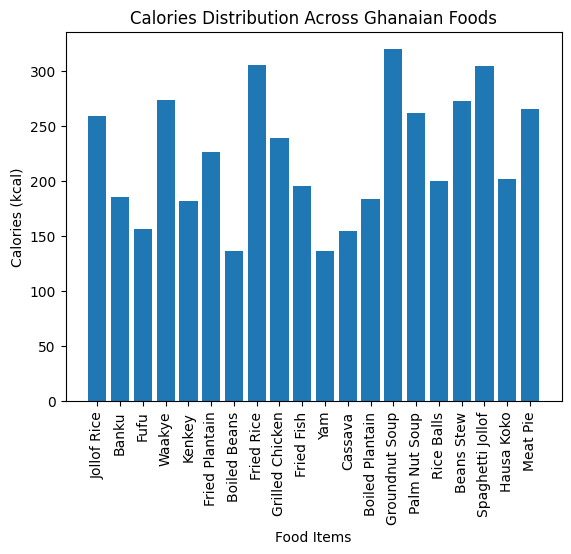

In [48]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(df["Food"], df["Calories"])
plt.xticks(rotation=90)
plt.xlabel("Food Items")
plt.ylabel("Calories (kcal)")
plt.title("Calories Distribution Across Ghanaian Foods")
plt.show()

### Nutrient Heatmap

#### What this visualization shows:

The heatmap highlights the concentration of nutrients across foods.

#### Key Observations:
- **Groundnut Soup** and **Palm Nut Soup** are very high in fat.
- **Boiled Beans** and **Chicken** are high in protein.
- Most staple foods (Banku, Fufu, Rice) are high in carbohydrates.

#### Health Insight:
- High fat foods : may increase cholesterol levels
- High carbohydrate foods : may spike blood sugar levels

> Individuals with:
> - **Diabetes** should limit high-carb foods
> - **Heart conditions** should monitor high-fat foods

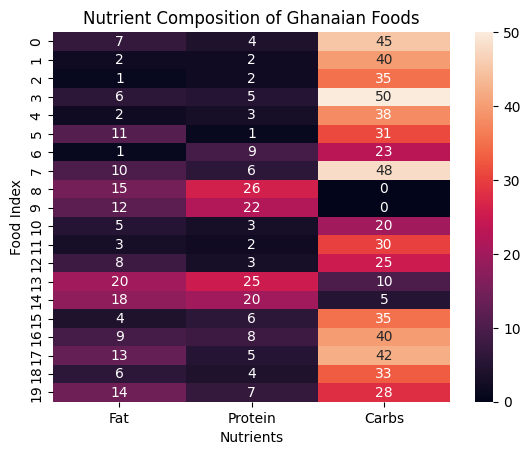

In [49]:
import seaborn as sns

plt.figure()
sns.heatmap(df[["Fat","Protein","Carbs"]], annot=True)
plt.title("Nutrient Composition of Ghanaian Foods")
plt.xlabel("Nutrients")
plt.ylabel("Food Index")
plt.show()

### Health Category Distribution

#### What this visualization shows:

This chart shows how many foods fall into each health category.

#### Key Observations:
- A large portion of foods fall into the **moderate** and **high-calorie** categories.
- Fewer foods are classified as low-calorie (healthy).

#### Health Insight:
This suggests that many commonly consumed foods are calorie-dense.

> This reinforces the need for:
> - Portion control
> - Balanced diet planning

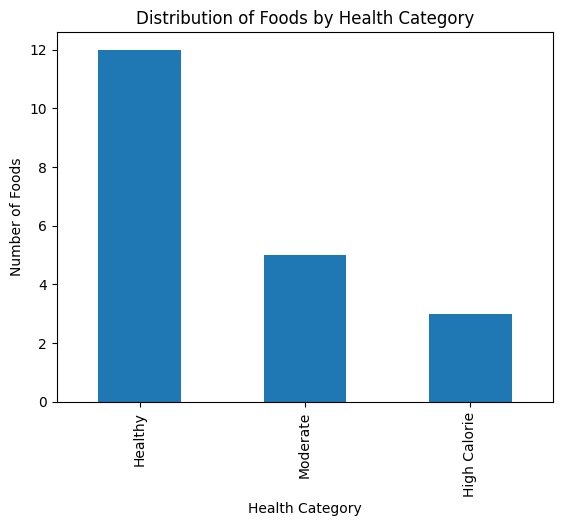

In [50]:
plt.figure()
df["Health"].value_counts().plot(kind='bar')
plt.xlabel("Health Category")
plt.ylabel("Number of Foods")
plt.title("Distribution of Foods by Health Category")
plt.show()

### Scatter Plot (Fat vs Calories)

#### What this visualization shows:

This scatter plot shows how fat content affects total calories.

#### Key Observations:
- Foods with higher fat content tend to have higher calories.
- There is a clear upward trend.

####  Health Insight:
Fat contributes the most to calorie increase (9 kcal per gram).

>  High-fat diets can lead to:
> - Obesity
> - Heart disease
>
> However, not all fat is bad. Balance is key.

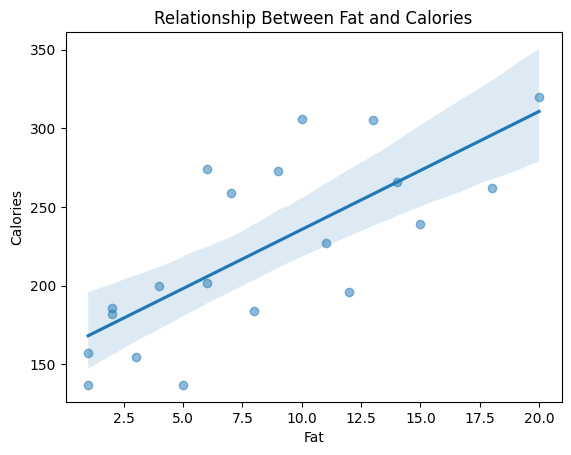

In [51]:
import seaborn as sns

sns.regplot(data=df, x="Fat", y="Calories", scatter_kws={'alpha':0.5})
plt.title("Relationship Between Fat and Calories")
plt.show()

### Protein vs Calories (Health Balance Insight)

#### What this visualization shows:

This plot compares protein content with total calories.

#### Key Observations:
- Some foods are high in protein but not excessively high in calories (e.g., beans).
- Others combine high protein with high fat equals very calorie dense.

#### Health Insight:
Protein is essential for body repair and muscle growth.

> Excess protein (especially with fat) can strain the kidneys over time.
>
> Balance is important.

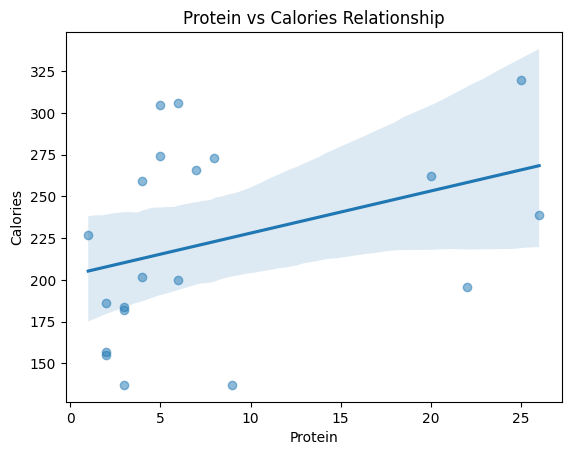

In [52]:
sns.regplot(data=df, x="Protein", y="Calories",  scatter_kws={'alpha':0.5})
plt.title("Protein vs Calories Relationship")
plt.show()

##  Normalization

#### Why normalization is important:

Different nutrients have different scales:
- Carbs may be 50g
- Protein may be 5g

**Without normalization:**
> Carbs dominate the analysis

**After normalization:**
- Data is centered around 0
- All features are equally important

#### Meaning:
- **Positive value** = above average
- **Zero value** = average
- **Negative value** = below average

This helps in identifying extreme foods (outliers).

In [53]:
mean = foods_np.mean(axis=0)
std = foods_np.std(axis=0)

normalized = (foods_np - mean) / std

print("Normalized Data:")
print(normalized)

Normalized Data:
[[-0.24433639 -0.52608621  1.08598021]
 [-1.14928597 -0.77962174  0.74871928]
 [-1.33027589 -0.77962174  0.41145834]
 [-0.4253263  -0.39931845  1.42324115]
 [-1.14928597 -0.65285397  0.6138149 ]
 [ 0.47962328 -0.9063895   0.14164959]
 [-1.33027589  0.1077526  -0.3979679 ]
 [ 0.29863336 -0.27255069  1.28833677]
 [ 1.20358295  2.26280455 -1.9493682 ]
 [ 0.6606132   1.7557335  -1.9493682 ]
 [-0.60631622 -0.65285397 -0.60032446]
 [-0.96829605 -0.77962174  0.07419741]
 [-0.06334647 -0.65285397 -0.26306353]
 [ 2.10853253  2.13603679 -1.27484633]
 [ 1.7465527   1.50219798 -1.61210727]
 [-0.78730614 -0.27255069  0.41145834]
 [ 0.11764345 -0.01901516  0.74871928]
 [ 0.84160311 -0.39931845  0.88362365]
 [-0.4253263  -0.52608621  0.27655397]
 [ 1.02259303 -0.14578293 -0.06070697]]


In [54]:
df_normalized = pd.DataFrame(normalized, columns=["Fat_norm", "Protein_norm", "Carbs_norm"])
df_normalized["Food"] = food_names         
df_normalized["Calories"] = total_calories 

df_normalized

,Fat_norm,Protein_norm,Carbs_norm,Food,Calories
0,-0.244336,-0.526086,1.085980,Jollof Rice,259.0
1,-1.149286,-0.779622,0.748719,Banku,186.0
2,-1.330276,-0.779622,0.411458,Fufu,157.0
3,-0.425326,-0.399318,1.423241,Waakye,274.0
4,-1.149286,-0.652854,0.613815,Kenkey,182.0
5,0.479623,-0.906389,0.141650,Fried Plantain,227.0
6,-1.330276,0.107753,-0.397968,Boiled Beans,137.0
7,0.298633,-0.272551,1.288337,Fried Rice,306.0
8,1.203583,2.262805,-1.949368,Grilled Chicken,239.0
9,0.660613,1.755734,-1.949368,Fried Fish,196.0


## Health Risk Analysis

### Health Risk Logic

Instead of just classifying by calories, we now evaluate foods based on **three major health concerns**:

1. **Diabetes Risk** : Foods high in carbohydrates can increase blood sugar levels.
2. **Heart Disease Risk** : Foods high in fat may increase cholesterol levels.
3. **Protein Benefit** : Protein supports muscle growth and body repair, but excess intake may have downsides.

These classifications are simplified but reflect real-world health considerations.

## Diabetes Risk

In [55]:
diabetes_labels = np.array(["High", "Moderate", "Low"])

df["Diabetes_Risk"] = np.where(
    df["Carbs"] > 40, diabetes_labels[0],
    np.where(df["Carbs"] > 25, diabetes_labels[1], diabetes_labels[2])
)
df[["Food", "Fat", "Protein", "Carbs", "Calories", "Diabetes_Risk"]]



,Food,Fat,Protein,Carbs,Calories,Diabetes_Risk
0,Jollof Rice,7.0,4.0,45.0,259.0,High
1,Banku,2.0,2.0,40.0,186.0,Moderate
2,Fufu,1.0,2.0,35.0,157.0,Moderate
3,Waakye,6.0,5.0,50.0,274.0,High
4,Kenkey,2.0,3.0,38.0,182.0,Moderate
5,Fried Plantain,11.0,1.0,31.0,227.0,Moderate
6,Boiled Beans,1.0,9.0,23.0,137.0,Low
7,Fried Rice,10.0,6.0,48.0,306.0,High
8,Grilled Chicken,15.0,26.0,0.0,239.0,Low
9,Fried Fish,12.0,22.0,0.0,196.0,Low


### Visualization: Diabetes Risk Distribution

#### Insight:

This chart shows how many foods fall into each diabetes risk category.

#### Meaning:
- Many Ghanaian foods are high in carbohydrates.
- Frequent consumption of high-carb foods may increase risk of diabetes.

> Individuals managing blood sugar should prioritize low to moderate carb foods.

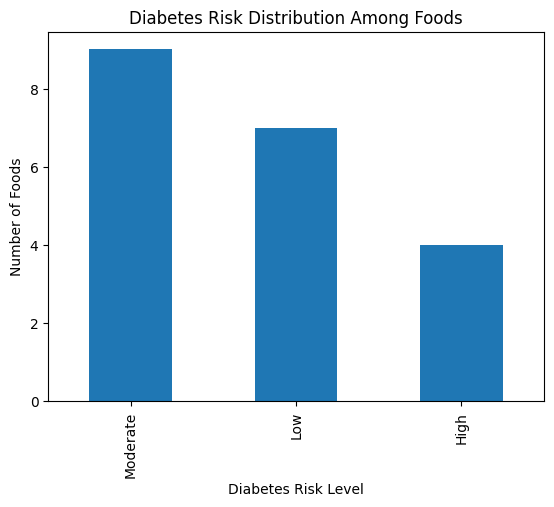

In [56]:
plt.figure()
df["Diabetes_Risk"].value_counts().plot(kind="bar")
plt.xlabel("Diabetes Risk Level")
plt.ylabel("Number of Foods")
plt.title("Diabetes Risk Distribution Among Foods")
plt.show()

## Heart Disease Risk

In [57]:
heart_labels = np.array(["High", "Moderate", "Low"])

df["Heart_Risk"] = np.where(
    df["Fat"] > 15, heart_labels[0],
    np.where(df["Fat"] > 8, heart_labels[1], heart_labels[2])
)
df[["Food", "Fat", "Protein", "Carbs", "Calories", "Diabetes_Risk"]]



,Food,Fat,Protein,Carbs,Calories,Diabetes_Risk
0,Jollof Rice,7.0,4.0,45.0,259.0,High
1,Banku,2.0,2.0,40.0,186.0,Moderate
2,Fufu,1.0,2.0,35.0,157.0,Moderate
3,Waakye,6.0,5.0,50.0,274.0,High
4,Kenkey,2.0,3.0,38.0,182.0,Moderate
5,Fried Plantain,11.0,1.0,31.0,227.0,Moderate
6,Boiled Beans,1.0,9.0,23.0,137.0,Low
7,Fried Rice,10.0,6.0,48.0,306.0,High
8,Grilled Chicken,15.0,26.0,0.0,239.0,Low
9,Fried Fish,12.0,22.0,0.0,196.0,Low


### Visualization : Heart Risk (Fat vs Food)

#### Insight:

This chart highlights foods with high fat content.

#### Meaning:
- **Groundnut Soup** and **Palm Nut Soup** stand out as high-fat foods.
- Regular consumption of high-fat foods may increase heart disease risk.

> People with hypertension or heart conditions should consume these in moderation.

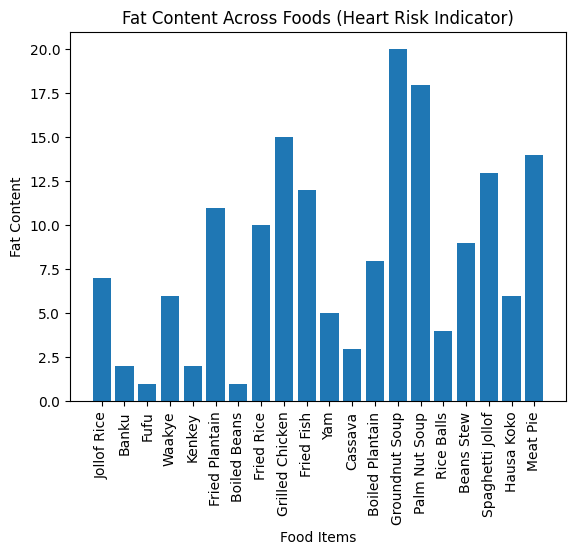

In [58]:
plt.figure()
plt.bar(df["Food"], df["Fat"])
plt.xticks(rotation=90)
plt.xlabel("Food Items")
plt.ylabel("Fat Content")
plt.title("Fat Content Across Foods (Heart Risk Indicator)")
plt.show()

## Protein Benefit

In [59]:
protein_labels = np.array(["High", "Moderate", "Low"])

df["Protein_Level"] = np.where(
    df["Protein"] > 20, protein_labels[0],
    np.where(df["Protein"] > 8, protein_labels[1], protein_labels[2])
)
df[["Food", "Fat", "Protein", "Carbs", "Calories", "Diabetes_Risk"]]

,Food,Fat,Protein,Carbs,Calories,Diabetes_Risk
0,Jollof Rice,7.0,4.0,45.0,259.0,High
1,Banku,2.0,2.0,40.0,186.0,Moderate
2,Fufu,1.0,2.0,35.0,157.0,Moderate
3,Waakye,6.0,5.0,50.0,274.0,High
4,Kenkey,2.0,3.0,38.0,182.0,Moderate
5,Fried Plantain,11.0,1.0,31.0,227.0,Moderate
6,Boiled Beans,1.0,9.0,23.0,137.0,Low
7,Fried Rice,10.0,6.0,48.0,306.0,High
8,Grilled Chicken,15.0,26.0,0.0,239.0,Low
9,Fried Fish,12.0,22.0,0.0,196.0,Low


### Visualization : Protein Benefit

#### Insight:

This chart shows how protein is distributed across foods.

#### Meaning:
- Protein-rich foods are fewer compared to carb-heavy foods.
- This shows an imbalance in typical diets.

> Increasing protein intake moderately can improve nutrition balance.

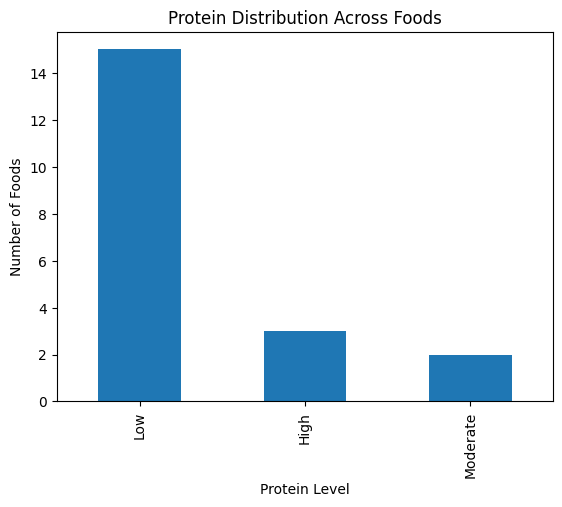

In [60]:
plt.figure()
df["Protein_Level"].value_counts().plot(kind="bar")
plt.xlabel("Protein Level")
plt.ylabel("Number of Foods")
plt.title("Protein Distribution Across Foods")
plt.show()

### Visualization : Carbs vs Fat

####  Insight:

This plot shows how foods balance carbs and fats.

####  Observations:
- Some foods are high in both. This maps up to higher health risk
- Others are balanced equals better dietary choices

> Balanced foods are generally safer for long-term consumption.

#### Simple Takeaways:
- **High carbs + high fat** : usually processed, calorie‑dense. Best as occasional treats.
- **Low carbs + low fat** : lean proteins, vegetables. Great for low‑calorie, nutrient‑dense eating.
- **Balanced middle** : whole foods (nuts, legumes, whole grains). Good for steady energy.
- **Bottom line**: Foods in the top‑right corner carry higher health risk if eaten often; aim for balanced or low‑fat/low‑carb choices for everyday meals.

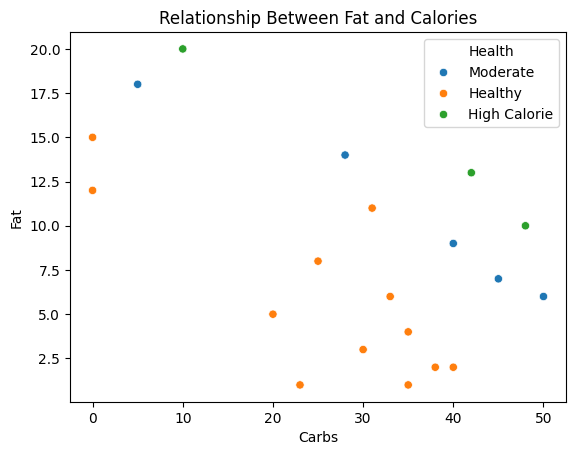

In [61]:
sns.scatterplot(data=df, x="Carbs", y="Fat", hue="Health")
plt.title("Relationship Between Fat and Calories")
plt.show()

### Visualization: Combined Overall Risk 

#### Insight:

This combines multiple health risks into one view.

#### Meaning:
- Foods high in **both fat and carbs** are the most risky.
- These should be consumed less frequently.

> This gives a more realistic picture than just calories alone.

In [62]:
risk_labels = np.array(["Very High", "High", "Moderate/Low"])

df["Overall_Risk"] = np.where(
    (df["Diabetes_Risk"] == "High") & (df["Heart_Risk"] == "High"), risk_labels[0],
    np.where(
        (df["Diabetes_Risk"] == "High") | (df["Heart_Risk"] == "High"), risk_labels[1],
        risk_labels[2]
    )
)

df[["Food", "Fat", "Protein", "Diabetes_Risk", "Heart_Risk", "Overall_Risk"]]

,Food,Fat,Protein,Diabetes_Risk,Heart_Risk,Overall_Risk
0,Jollof Rice,7.0,4.0,High,Low,High
1,Banku,2.0,2.0,Moderate,Low,Moderate/Low
2,Fufu,1.0,2.0,Moderate,Low,Moderate/Low
3,Waakye,6.0,5.0,High,Low,High
4,Kenkey,2.0,3.0,Moderate,Low,Moderate/Low
5,Fried Plantain,11.0,1.0,Moderate,Moderate,Moderate/Low
6,Boiled Beans,1.0,9.0,Low,Low,Moderate/Low
7,Fried Rice,10.0,6.0,High,Moderate,High
8,Grilled Chicken,15.0,26.0,Low,Moderate,Moderate/Low
9,Fried Fish,12.0,22.0,Low,Moderate,Moderate/Low


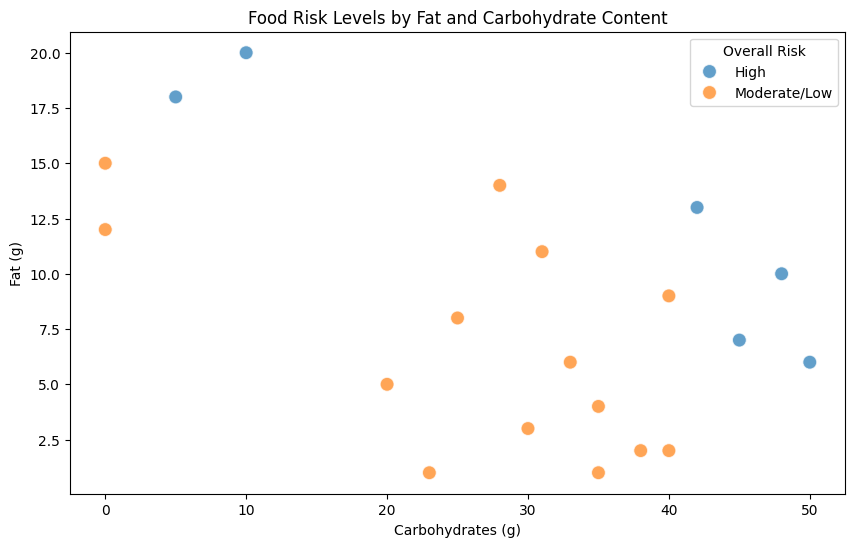

In [63]:


# Create the scatter plot
plt.figure(figsize=(10,6))
sns.scatterplot( data=df, x="Carbs", y="Fat", hue="Overall_Risk", s=100, alpha=0.7)

# Add labels and title
plt.xlabel("Carbohydrates (g)")
plt.ylabel("Fat (g)")
plt.title("Food Risk Levels by Fat and Carbohydrate Content")
plt.legend(title="Overall Risk")
plt.show()


##  Final Insights & Real-World Meaning

### Key Learnings from this Project:

1. Many Ghanaian foods are calorie-dense due to high fat and carbohydrate content.

2. Foods like **Groundnut Soup**, **Palm Nut Soup**, and **Fried Rice** are high in calories and should be consumed in moderation.

3. Foods like **Boiled Beans** and **Yam** provide better nutritional balance.

4. Fat contributes the most to calorie increase, making it a key factor in diet planning.

5. Many Ghanaian foods are carbohydrate-heavy, increasing potential diabetes risk.

6. Protein-rich foods are fewer, suggesting an imbalance in diet composition.

7. Foods that are high in **both fat and carbs** present the highest overall health risk.


### Recommendations:

- **For Diabetes:**
    Reduce intake of high-carb foods like rice and cassava

- **For Heart Health:**
    Limit high-fat foods like palm nut and groundnut soup

- **For Balanced Diet:**
    Include more protein-rich foods like beans and lean meat

- **General population:**
    Aim for balanced meals with controlled portions



### Conclusion

This project shows how simple tools like **NumPy**, **Pandas**, and **visualization** can be used to:
- Analyze real-world data
- Draw meaningful health insights
- Support better food decisions

By combining these tools:
>  I transformed raw food data into meaningful health recommendations.

**Data is not just numbers. It tells a story about how we live.**